Task 1 — Data Loading & Exploration

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Housing.csv") 

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
rows,cols = df.shape
print("Total Number of rows: ",rows)
print("Total Number of cols: ",cols)

Total Number of rows:  545
Total Number of cols:  13


In [6]:
target = df['price']
features = df.drop(columns=['price'])

print(f"Target column: price")
print(f"Feature columns: {list(features.columns)}")


Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


Task 2 — Data Cleaning

In [8]:
missing_vals = df.isnull().sum()
print(missing_vals)

#In this cell we can see that there are no missing values hence there is no need to handle them

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [9]:
duplicates = df.duplicated().sum()
print(duplicates)

#We can see that the output is 0 which means there are no duplicates present

0


In [10]:
print(df.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [11]:
# colums that have object data type are categorical hence they need to be converted
# get_dummies function is used to perform one-hot encoding

df = pd.get_dummies(df, columns= ['mainroad' ,'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'],
                   drop_first=True)

In [12]:
print(df.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


Task 3 — Model Building

In [14]:
# we differentiate our target and other features
Y = df['price']
X = df.drop('price', axis=1)

In [15]:
#spiltting training and test data
#importing train_test split from sklearn 
from sklearn.model_selection import train_test_split

X_train, X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [18]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

In [19]:
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2 score: ",r2)

MAE:  970043.4039201637
MSE:  1754318687330.6643
RMSE:  1324506.9600914388
R2 score:  0.6529242642153184


In [20]:
#Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,Y_train)

rf_pred = rf.predict(X_test)

In [21]:
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(Y_test, rf_pred)

In [22]:
print("RF MAE: ",rf_mae)
print("RF MSE: ",rf_mse)
print("RF RMSE: ",rf_rmse)
print("RF R2 score: ",rf_r2)

RF MAE:  1021546.0353211008
RF MSE:  1961585044320.3433
RF RMSE:  1400565.9728553821
RF R2 score:  0.611918531405699


Task 4 — Visualization 


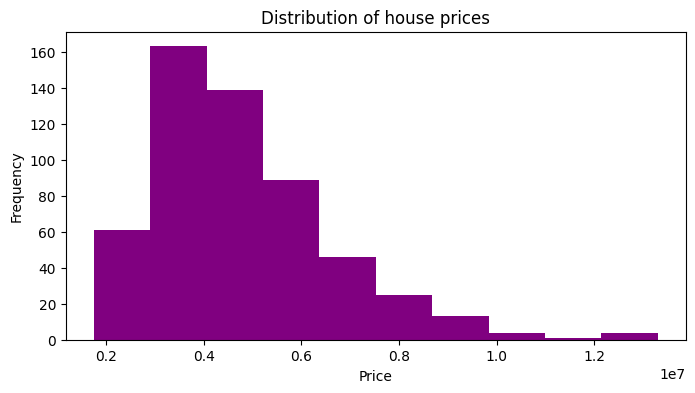

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
plt.hist(df['price'],bins=10, color="purple")
plt.title('Distribution of house prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig('chart1.png', dpi=300, bbox_inches='tight')

plt.show()

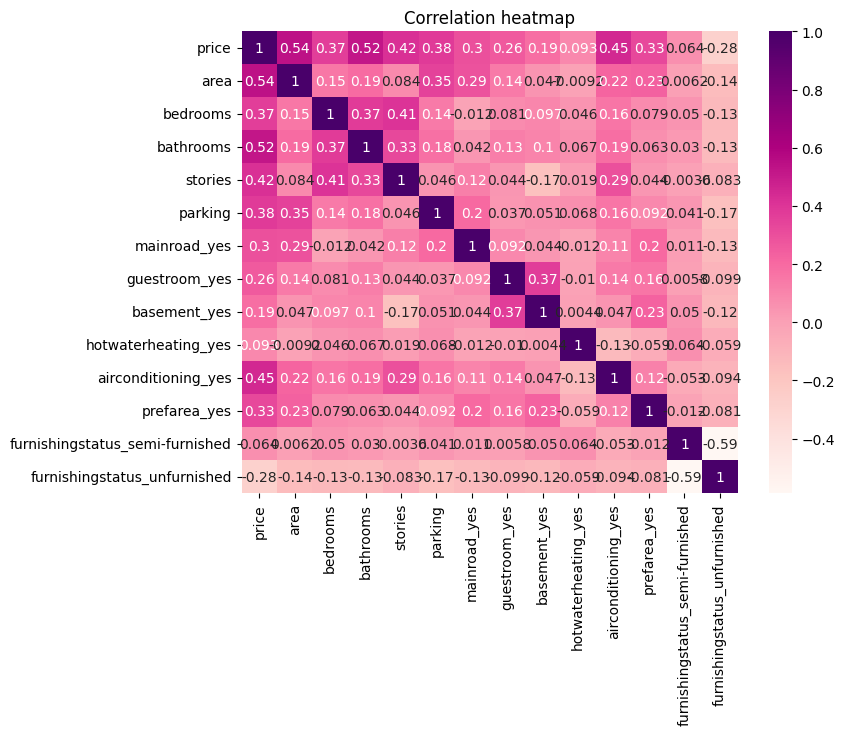

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='RdPu')
plt.title('Correlation heatmap')
plt.savefig('chart2.png', dpi=300, bbox_inches='tight')

plt.show()

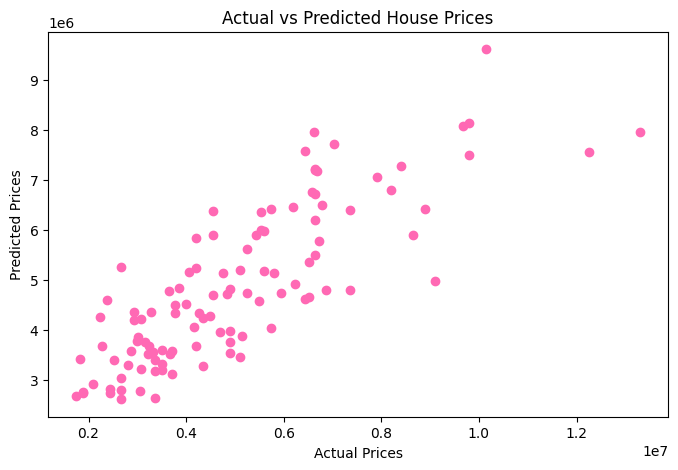

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(Y_test, Y_pred, color='hotpink')

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.savefig('chart3.png', dpi=300, bbox_inches='tight')

plt.show()

#ANALYSIS

On analysis it was observed that the features (area, bathrooms , bedroom and stories) has the most impact on the house prices 

When we evaluated the predictions the R2 score was around 0.65 this states that our linear regression model was able to explain around 65% of the variations that was present in house prices and it also gave accurate predictions.

One of the surprising point was that random forest regressor performed bad in comparison to linear regression even though complex model do perform well generally.

we noticed that expensive properties didnt have much sale so real estate buisness should focus on providing upto the mark amenties with the larger properties to encourage more sale.